Importing the Dependencies

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Data Collection & Analysis

In [44]:
# loading the data from csv file to a Pandas DataFrame
file_path = r"C:\Users\Aagam\Code Playground\ML Project\data\parkinson's-disease-dataset.xls"
df = pd.read_csv(file_path)
parkinsons_data = df.drop(columns='name')

In [45]:
# printing the first 5 rows of the dataframe
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [46]:
# number of rows and columns in the dataframe
df.shape

(195, 24)

In [47]:
# getting more information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

In [48]:
parkinsons_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       195 non-null    float64
 1   MDVP:Fhi(Hz)      195 non-null    float64
 2   MDVP:Flo(Hz)      195 non-null    float64
 3   MDVP:Jitter(%)    195 non-null    float64
 4   MDVP:Jitter(Abs)  195 non-null    float64
 5   MDVP:RAP          195 non-null    float64
 6   MDVP:PPQ          195 non-null    float64
 7   Jitter:DDP        195 non-null    float64
 8   MDVP:Shimmer      195 non-null    float64
 9   MDVP:Shimmer(dB)  195 non-null    float64
 10  Shimmer:APQ3      195 non-null    float64
 11  Shimmer:APQ5      195 non-null    float64
 12  MDVP:APQ          195 non-null    float64
 13  Shimmer:DDA       195 non-null    float64
 14  NHR               195 non-null    float64
 15  HNR               195 non-null    float64
 16  status            195 non-null    int64  
 17  RPDE    

In [49]:
parkinsons_data.shape

(195, 23)

In [50]:
# checking for missing values in each column
parkinsons_data.isnull().sum()

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [51]:
# getting some statistical measures about the data
parkinsons_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [52]:
# distribution of target Variable
parkinsons_data['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

1  --> Parkinson's Positive

0 --> Healthy


In [53]:
# grouping the data bas3ed on the target variable
parkinsons_data.groupby('status').mean()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.000023,0.001925,0.002056,0.005776,0.017615,0.162958,...,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.000051,0.003757,0.003900,0.011273,0.033658,0.321204,...,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


### Target Distribution

C:\Users\Aagam\AppData\Local\Temp\ipykernel_13236\473582076.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=parkinsons_data, palette=['green','red'])


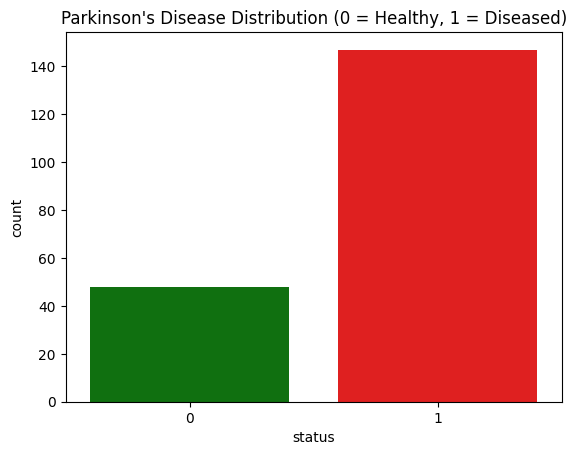

In [54]:
sns.countplot(x='status', data=parkinsons_data, palette=['green','red'])
plt.title("Parkinson's Disease Distribution (0 = Healthy, 1 = Diseased)")
plt.show()

### MDVP:Fo(Hz) (Fundamental Frequency) vs Disease

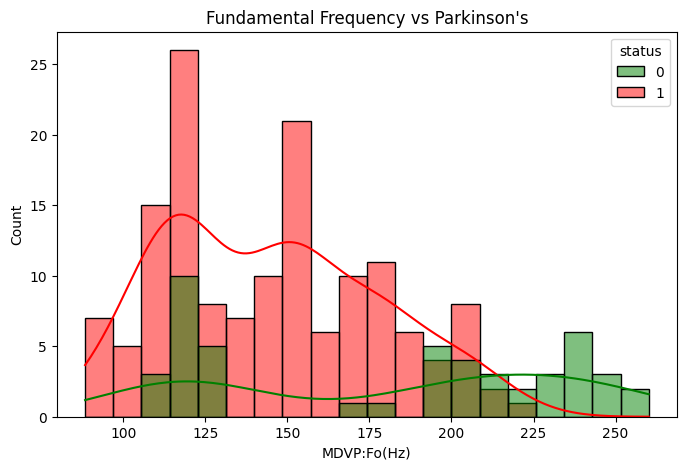

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(data=parkinsons_data, x='MDVP:Fo(Hz)', hue='status',
             bins=20, kde=True, palette=['green','red'])
plt.title("Fundamental Frequency vs Parkinson's")
plt.show()

### Jitter vs Disease

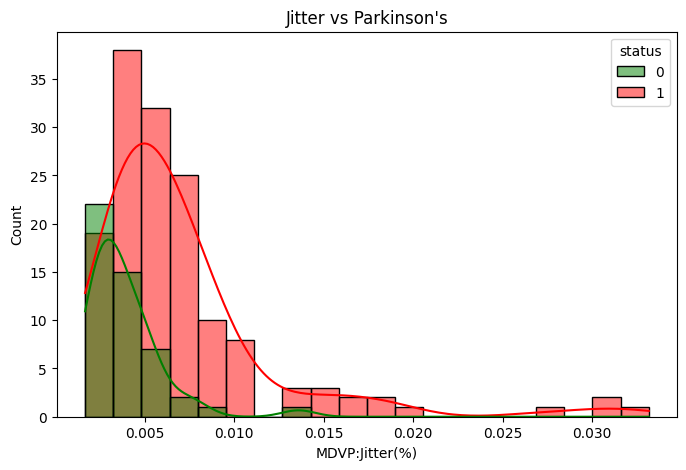

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(data=parkinsons_data, x='MDVP:Jitter(%)', hue='status',
             bins=20, kde=True, palette=['green','red'])
plt.title("Jitter vs Parkinson's")
plt.show()

### Shimmer vs Disease

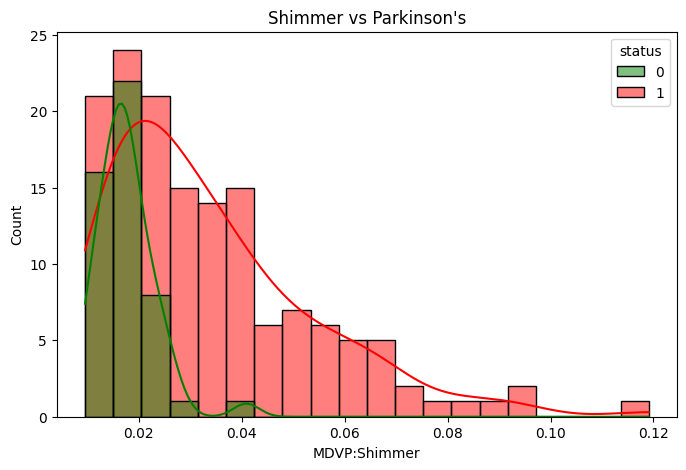

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(data=parkinsons_data, x='MDVP:Shimmer', hue='status',
             bins=20, kde=True, palette=['green','red'])
plt.title("Shimmer vs Parkinson's")
plt.show()

### Harmonics-to-Noise Ratio (HNR)

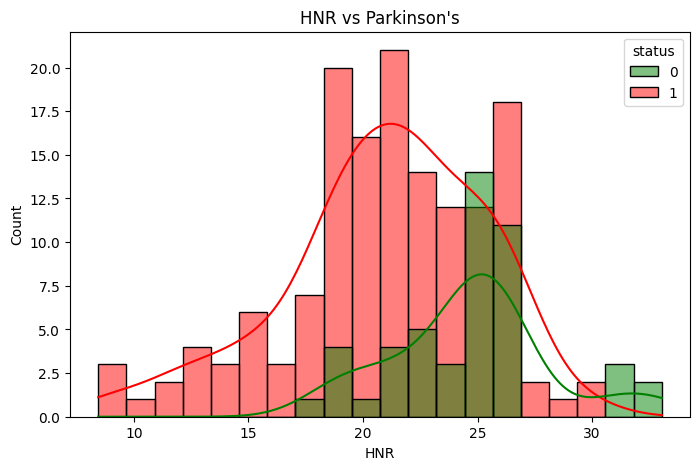

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(data=parkinsons_data, x='HNR', hue='status',
             bins=20, kde=True, palette=['green','red'])
plt.title("HNR vs Parkinson's")
plt.show()

### Boxplot (Jitter Comparison)

C:\Users\Aagam\AppData\Local\Temp\ipykernel_13236\23484222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='MDVP:Jitter(%)', data=parkinsons_data,


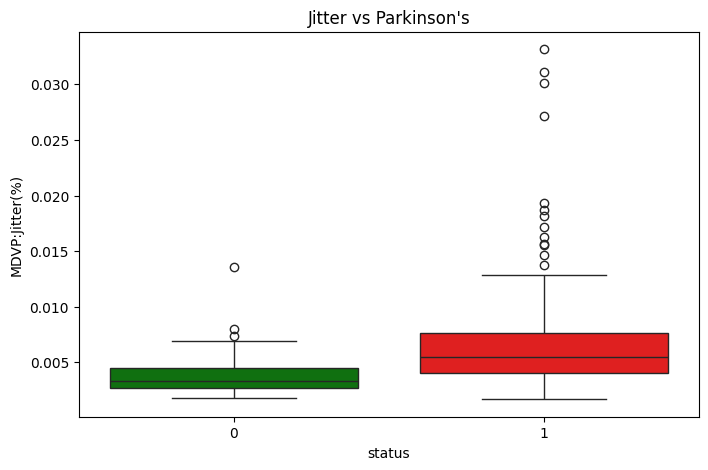

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x='status', y='MDVP:Jitter(%)', data=parkinsons_data,
            palette=['green','red'])
plt.title("Jitter vs Parkinson's")
plt.show()

### Boxplot (Shimmer Comparison)

C:\Users\Aagam\AppData\Local\Temp\ipykernel_13236\3199859130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='MDVP:Shimmer', data=parkinsons_data,


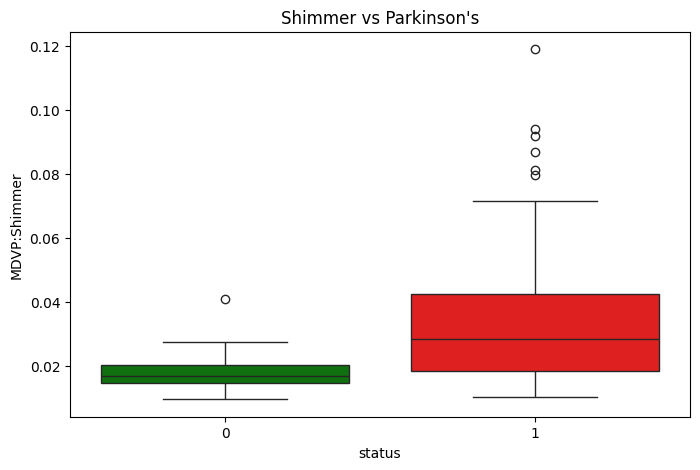

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x='status', y='MDVP:Shimmer', data=parkinsons_data,
            palette=['green','red'])
plt.title("Shimmer vs Parkinson's")
plt.show()

### Correlation Heatmap

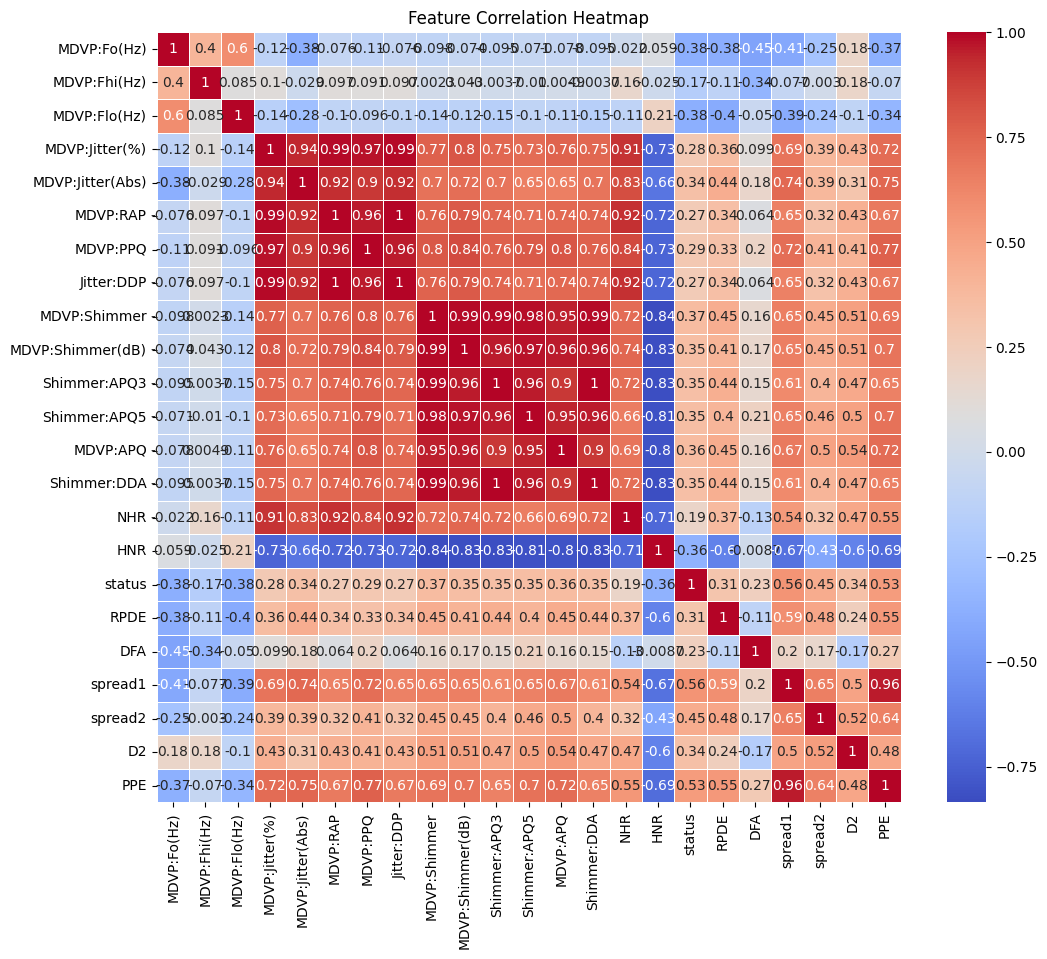

In [61]:
plt.figure(figsize=(12,10))
sns.heatmap(parkinsons_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Data Pre-Processing

Separating the features & Target

In [63]:
X = parkinsons_data.drop(columns=['status'])
Y = parkinsons_data['status']

In [64]:
print(X)

     MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0        119.992       157.302        74.997         0.00784   
1        122.400       148.650       113.819         0.00968   
2        116.682       131.111       111.555         0.01050   
3        116.676       137.871       111.366         0.00997   
4        116.014       141.781       110.655         0.01284   
..           ...           ...           ...             ...   
190      174.188       230.978        94.261         0.00459   
191      209.516       253.017        89.488         0.00564   
192      174.688       240.005        74.287         0.01360   
193      198.764       396.961        74.904         0.00740   
194      214.289       260.277        77.973         0.00567   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0             0.00007   0.00370   0.00554     0.01109       0.04374   
1             0.00008   0.00465   0.00696     0.01394       0.06134   
2             0.00

In [65]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64


Splitting the data to training data & Test data

In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [67]:
print(X.shape, X_train.shape, X_test.shape)

(195, 22) (156, 22) (39, 22)


Data Standardization

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [69]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

In [71]:
print(X_train)

[[ 0.63239631 -0.02731081 -0.87985049 ... -0.97586547 -0.55160318
   0.07769494]
 [-1.05512719 -0.83337041 -0.9284778  ...  0.3981808  -0.61014073
   0.39291782]
 [ 0.02996187 -0.29531068 -1.12211107 ... -0.43937044 -0.62849605
  -0.50948408]
 ...
 [-0.9096785  -0.6637302  -0.160638   ...  1.22001022 -0.47404629
  -0.2159482 ]
 [-0.35977689  0.19731822 -0.79063679 ... -0.17896029 -0.47272835
   0.28181221]
 [ 1.01957066  0.19922317 -0.61914972 ... -0.716232    1.23632066
  -0.05829386]]


Model Training

In [72]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, Y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# 2. SVM
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, Y_train)

svm_train_pred = svm_model.predict(X_train)
svm_test_pred = svm_model.predict(X_test)

# 3. Decision Tree
dt_model = DecisionTreeClassifier(random_state=2)
dt_model.fit(X_train, Y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# 4. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

Model Evaluation

In [73]:
def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, model_name):

    print(f"\n🔹 {model_name}")

    print("\nTrain:")
    print("Accuracy :", accuracy_score(y_train, y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall   :", recall_score(y_train, y_train_pred))
    print("F1 Score :", f1_score(y_train, y_train_pred))

    print("\nTest:")
    print("Accuracy :", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall   :", recall_score(y_test, y_test_pred))
    print("F1 Score :", f1_score(y_test, y_test_pred))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

In [74]:
# Evaluate all models
evaluate_model(Y_train, lr_train_pred, Y_test, lr_test_pred, "Logistic Regression")
evaluate_model(Y_train, svm_train_pred, Y_test, svm_test_pred, "SVM")
evaluate_model(Y_train, dt_train_pred, Y_test, dt_test_pred, "Decision Tree")
evaluate_model(Y_train, rf_train_pred, Y_test, rf_test_pred, "Random Forest")


🔹 Logistic Regression

Train:
Accuracy : 0.8717948717948718
Precision: 0.8934426229508197
Recall   : 0.9396551724137931
F1 Score : 0.9159663865546218

Test:
Accuracy : 0.8205128205128205
Precision: 0.9
Recall   : 0.8709677419354839
F1 Score : 0.8852459016393442

Confusion Matrix:
 [[ 5  3]
 [ 4 27]]

🔹 SVM

Train:
Accuracy : 0.8846153846153846
Precision: 0.8951612903225806
Recall   : 0.9568965517241379
F1 Score : 0.925

Test:
Accuracy : 0.8717948717948718
Precision: 0.90625
Recall   : 0.9354838709677419
F1 Score : 0.9206349206349206

Confusion Matrix:
 [[ 5  3]
 [ 2 29]]

🔹 Decision Tree

Train:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test:
Accuracy : 0.7435897435897436
Precision: 0.9565217391304348
Recall   : 0.7096774193548387
F1 Score : 0.8148148148148148

Confusion Matrix:
 [[ 7  1]
 [ 9 22]]

🔹 Random Forest

Train:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test:
Accuracy : 0.8205128205128205
Precision: 0.9
Recall   : 0.8709677419354839
F1 

In [75]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],

    'Train Accuracy': [
        accuracy_score(Y_train, lr_train_pred),
        accuracy_score(Y_train, svm_train_pred),
        accuracy_score(Y_train, dt_train_pred),
        accuracy_score(Y_train, rf_train_pred)
    ],

    'Test Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ]
})

print("\nTrain vs Test Accuracy:\n", comparison)


Train vs Test Accuracy:
                  Model  Train Accuracy  Test Accuracy
0  Logistic Regression        0.871795       0.820513
1                  SVM        0.884615       0.871795
2        Decision Tree        1.000000       0.743590
3        Random Forest        1.000000       0.820513


In [76]:
comparison_full = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],

    'Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ],

    'Precision': [
        precision_score(Y_test, lr_test_pred),
        precision_score(Y_test, svm_test_pred),
        precision_score(Y_test, dt_test_pred),
        precision_score(Y_test, rf_test_pred)
    ],

    'Recall': [
        recall_score(Y_test, lr_test_pred),
        recall_score(Y_test, svm_test_pred),
        recall_score(Y_test, dt_test_pred),
        recall_score(Y_test, rf_test_pred)
    ],

    'F1 Score': [
        f1_score(Y_test, lr_test_pred),
        f1_score(Y_test, svm_test_pred),
        f1_score(Y_test, dt_test_pred),
        f1_score(Y_test, rf_test_pred)
    ]
})

print("\n📊 Full Model Comparison:\n")
print(comparison_full)


📊 Full Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.820513   0.900000  0.870968  0.885246
1                  SVM  0.871795   0.906250  0.935484  0.920635
2        Decision Tree  0.743590   0.956522  0.709677  0.814815
3        Random Forest  0.820513   0.900000  0.870968  0.885246


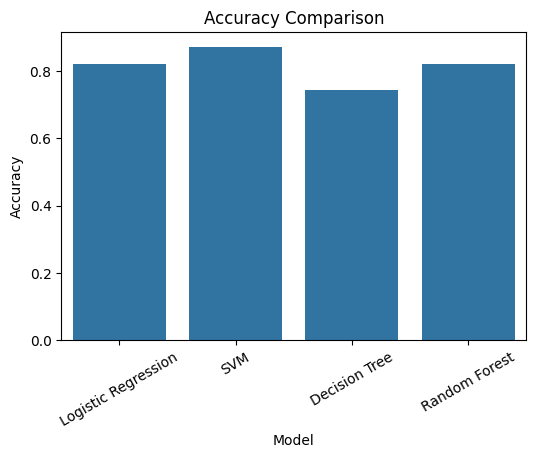

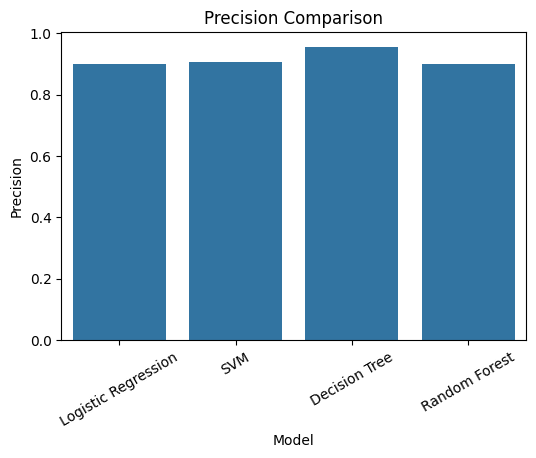

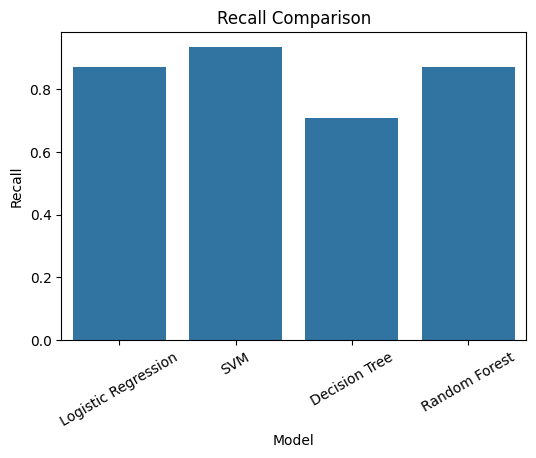

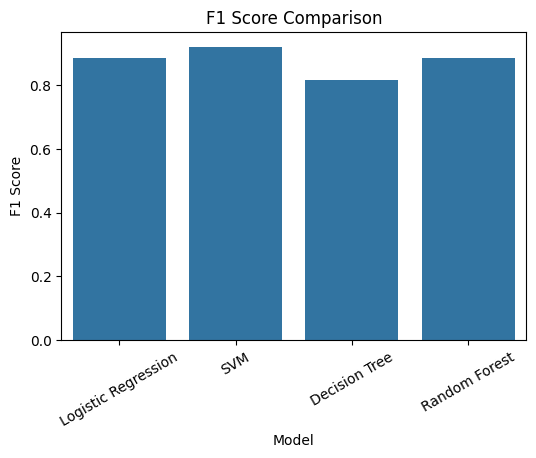

In [77]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Model', y=metric, data=comparison_full)
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=30)
    plt.show()

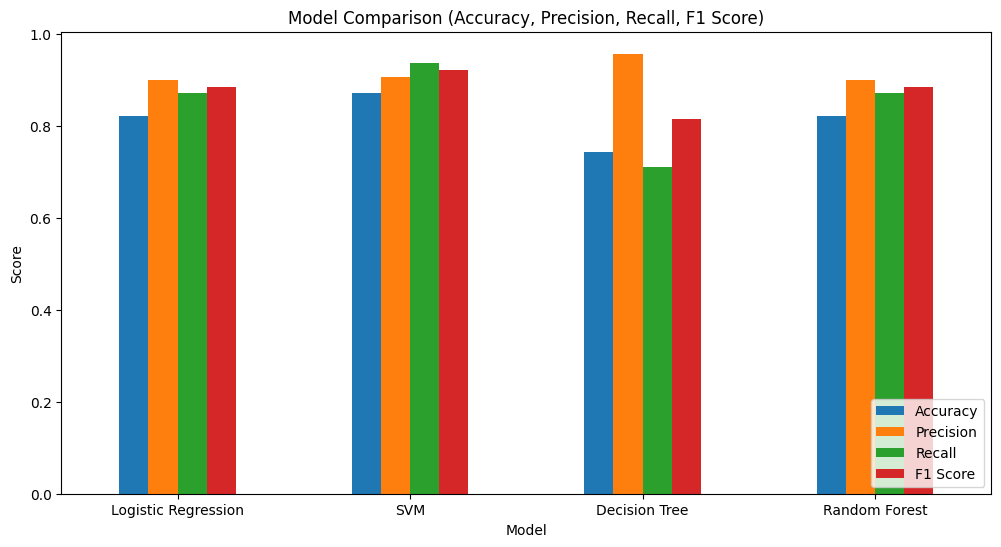

In [78]:
comparison_full.set_index('Model').plot(kind='bar', figsize=(12,6))

plt.title("Model Comparison (Accuracy, Precision, Recall, F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

Building a Predictive System

In [79]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the data
input_data_scaled = scaler.transform(input_data_reshaped)
print(input_data_scaled)

# SVM Prediction
svm_prediction = svm_model.predict(input_data_scaled)
print(svm_prediction)


if (svm_prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[[ 1.00729641  0.08037423  1.65523823 -0.68717144 -0.94428847 -0.56688934
  -0.644151   -0.56692742 -1.01996476 -0.97281357 -1.01502935 -0.95237979
  -0.96166669 -1.01502814 -0.54357444  1.11207622 -0.70087594  0.40606213
  -1.48926555 -0.56299141 -1.63837671 -1.31650398]]
[0]
The Person does not have Parkinsons Disease


c:\Users\Aagam\Code Playground\ML Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Saving the Model

In [80]:
import joblib

In [81]:
joblib.dump({
    'model': svm_model,
    'scaler': scaler
},'models/parkinsons_model.pkl')

['models/parkinsons_model.pkl']